Problem definition- You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 

Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.


week 1-> 2

Key Changes in Strategy and TuningFor 8 dimensions, we can't rely on simple local searches. We need a global strategy shift that prioritizes uncertainty.1. Strategic Shift: Aggressive Exploration (UCB)Acquisition FunctionParameter ChangeRationale (Simple Interpretation)Upper Confidence Bound (
)Set 
 (kappa) to 
 (High Exploration)
 balances the current best prediction (
) with uncertainty (
). A high 
 tells the model: "In this vast 8D space, it's worth taking a bigger risk to explore the unknown regions, as the reward might be a much higher, undiscovered peak."2. Hyperparameter Tuning: Computational BudgetParameter ChangeNew ValueRationale (Simple Interpretation)
 (GPR)
The model's fitting process in 8D is complex. Increasing the number of random starts significantly improves the reliability of the optimizer, giving it the best chance to find the true underlying function's parameters.
 (
 Search)
Similarly, this ensures the search for the next optimal query point is thorough, making sure we don't miss the best spot due to a poor starting guess in the complex 8D space.

week 2 -> 3

Function 8, with its 8 dimensions, is a prime example of the "curse of dimensionality." The search space is unimaginably vast, making a thorough, robust search strategy paramount.

Approach: Aggressive Search with Expected Improvement (EI) Your current strategy is the correct one. We must use Expected Improvement (EI) as it is designed to find the single global maximum. The primary challenge isn't the choice of acquisition function, but ensuring we can actually find its maximum value across 8 dimensions. To do this, we must continue to use a very high number of restarts (n_restarts) when optimizing EI. This aggressive search is the single most important part of the strategy, as it's our best defense against the enormous search space.

Hyperparameter Tuning: Automatic Learning with a Large Budget You do not need to make any manual changes to the model. The GP model's strength is its ability to learn automatically. When we call gp_f8.fit() with the now 41 data points, it will work to optimize all eight length_scale hyperparameters of its kernel. We will continue to give the GP's internal optimizer a generous budget (n_restarts_optimizer=30) to help it converge to a good solution, which is critical in such a high-dimensional space.

In essence, the strategy is to trust the process and give the optimizers the computational power they need to conduct a thorough search.

Week 3 -> 4
We've added the latest query (output 9.009...) to our dataset, bringing the total observations to 43.

This new point is not a record (best remains 9.8813), but it provides valuable data. The query was a deliberate exploration of the function's boundaries (using UCB with kappa=3.5). The high score confirms this area is promising, but likely not the true peak.

Strategy: Our strategy remains unchanged. Given the vast 8D space, 43 points is still very small, and we must continue to prioritize exploration. We will stick with UCB (kappa=3.5) and let the GP model automatically re-tune itself with the new data to find the next most promising, uncertain region.

Week 4 -> 5 

* **Successful Exploration:** our last score of **9.456**, while not a new record (best is 9.881), was a highly successful **exploration** step. It confirms we have found another valuable, high-performing region in the 8D space, which is critical for mapping the landscape.
* **Continue UCB Strategy:** The strategy remains focused on **aggressive exploration** using the **Upper Confidence Bound (UCB)** function, as 44 data points is still very small for 8 dimensions.
* **Keep High "Curiosity":** The `kappa` parameter will be **kept at 3.5**. Think of this as a "Curiosity Knob" turned up high, which is proving effective at discovering new, uncertain areas with good potential.
* **Maintain Search Budget:** We will **keep `n_restarts_optimizer = 100`** (the model's "thinking time") and **`n_restarts = 50`** (the "search party" for the next query) to ensure our model fit and exploration search remain thorough.
* for Week 4: Key Hyperparameter Learnings --- Learned Kernel Parameters: 3.21**2 * Matern(length_scale=[3.12, 4.79, 2.41, 4.86, 13.4, 4.67, 3.33, 3e+03], nu=2.5)

--Point to Query for Week 4 (Function 8) --- Suggested next input: [0.32106981 ,0., 0., 0., 1., 0., 0., 0.54648522]

## week 5 --> 6

Result Analysis: The Week 5 output (9.6109) is a strong result, currently the second-best score in the entire history (surpassed only by Week 2's 9.88). This validates the current trajectory. The input vector was sparse (containing four 0s), further suggesting that the optimum lies on the boundaries of the hypercube rather than the center.

Dimension Correlation: A consistent pattern is emerging: Dimension 5 (index 4) was set to 1.0 in the high-scoring Week 2, Week 4, and Week 5. This variable appears to be a critical "switch" that must be maximized.

Strategy Refinement (Shift to Balanced UCB): Previously, we used a very high kappa=3.5 for aggressive exploration. Since we have found a high-performing cluster (scores > 9.4), we should slightly reduce kappa to 2.5 or 3.0. This shifts the strategy from "wild exploration" to "focused exploration"—searching for the peak near these high-performing boundary points.

Hyperparameter Tuning: We retain the Matern 2.5 kernel (handles some roughness/discontinuity) but continue to allow the Automatic Relevance Determination (ARD) to execute. The GP will likely learn that Dimension 5 has a short length-scale (highly active) while others might be longer.
* Learned Kernel Length Scales:
2.33458989e+00, 4.62230142e+00, 2.30793726e+00, 3.77732436e+00,
 2.09259750e+01, 6.72445086e+03, 3.51253279e+00, 4.69186844e+03.

## Insight into Week 6 Result & Strategy for Week 7:
Based on the performance of the Week 6 input (Score: 9.2339) and the historical data in your notebook, here is the summary of the current status and the strategy for the upcoming week:Result Analysis: The Week 6 score ($9.23$) is solid (top quartile) but did not beat the Week 2 record ($9.88$) or Week 5 ($9.61$). This indicates that while we are in the correct "basin of attraction" (specifically with Dimension 5 set to 1.0), the specific combination of the other boundary values (0s and 1s) used in Week 6 was slightly sub-optimal.The "Anchor" Dimension: The data consistently shows that Dimension 5 (index 4) strongly correlates with high output when set to $1.0$. The GP model has likely learned this "switch," indicated by the high length scale for that dimension in previous iterations.Shift to Exploitation: We have spent Weeks 4, 5, and 6 exploring the boundaries with a high "curiosity" factor (kappa=3.0 to 3.5). Since we have a clear best point (Week 2) and a cluster of good points, ** we will reduce kappa to 1.96 (or 2.0). This shifts the strategy from "wild exploration" to "guided exploitation," asking the model to refine the area around the known best solutions rather than searching empty voids.Kernel Strategy: We retain the Matern 2.5 Kernel. The function landscape appears to have sharp drop-offs (scores dropping from 9.8 to 5.5 quickly in history), and Matern 2.5 handles these non-smooth transitions better than the RBF kernel.

## Insight into Week 7 Result & Strategy for Week 8
Validation of "Anchor" Dimension: The Week 7 score (9.6716) is the second-best result in the entire optimization history (surpassing Week 5's 9.61 and trailing only Week 2's 9.88). This confirms that locking Dimension 5 to 1.0 is the correct strategy, as all top three scores share this feature.

Successful Exploitation: Reducing kappa to 2.0 successfully shifted the model from "wild exploration" to "high-yield refinement." The optimizer located a stable, high-value region near the global maximum rather than wasting queries on low-probability areas.

Boundary Sensitivity: The input vector remains sparse (values near 0 for Dim 2 and Dim 7). This reinforces the hypothesis that the global maximum lies on the edges of the hypercube for several dimensions, while Dim 5 acts as the central "switch."

Strategy for Week 8 (Fine-Tuning): We are now deep in the "Exploitation" phase. We will further reduce kappa slightly to 1.96 (standard 95% confidence). The goal is no longer to find new mountains, but to climb to the very peak of the mountain we have found.

Hyperparameter Tuning: Continue using the Matérn 2.5 kernel. The function landscape is clearly non-smooth (jagged peaks), and Matérn handles these discontinuities better than the RBF kernel. The GP will automatically refine the length scales to recognize that Dim 5 is the most critical feature.

## Insight into Week 8 Result & Strategy for Week 9
1. Result Analysis (The "Twin" Peak): The Week 8 output (9.8813027) is effectively identical to the Week 2 record (9.881301). The input vectors differ only in the 5th/6th decimal places. This happened because the optimization strategy in Week 8 explicitly included the known_best point in its search restarts, causing the model (using a low kappa) to converge right back to the safe, known maximum.

2. Verification Complete: While we didn't gain a new record, this result is valuable: it confirms that the peak found in Week 2 is stable and not a random noise artifact. We have effectively "verified" the solution.

3. Strategy Shift (Break the Cycle): To beat 9.88, we must stop sampling this exact spot. For Week 9, we will switch from UCB (Upper Confidence Bound) to Expected Improvement (EI). EI is fundamentally designed to calculate the potential gain over the current best record, rather than just raw value.

4. Hyperparameter Tuning:

    Acquisition: Switch to Expected Improvement (EI) with xi=0.01. This low xi encourages exploitation (fine-tuning) but mathematically forces the model to look for points that offer an improvement over 9.88, rather than just high confidence at 9.88.

    Search Method: Crucially, we will remove the known_best point from the optimizer's random restarts. This forces the solver to discover the peak on its own or find a better adjacent sub-peak.

week 9 Learned Length Scales (Sensitivity of each dimension):
[1.00000000e+05 1.00000000e+05 1.45311533e-06 3.04288713e-04
 7.47074331e+04 1.00000000e-06 8.61395417e+04 8.79835438e+03]
   

## Insight into Week 9 Result & Strategy for Week 10
* Result Analysis (Regression): The Week 9 score (9.4443) was lower than the current record (9.8813). While 9.44 is still a high score, moving Dimensions 1 and 2 to higher values (around 0.5 and 0.47) resulted in a performance drop compared to the optimal region where they are near (~0.
15 and ~0.12).
* Landscape Confirmation: The result reinforces that the global maximum is likely extremely narrow ("needle in a haystack"). We now know that while Dimension 5 must remain high (~0.9 - 1.0), deviating significantly in the other dimensions moves us down the slope of the peak.
* Strategy Shift (Trust Region Optimization): We have tried global exploration (UCB) and global exploitation (EI). Now, with only a few weeks left, we must switch to Local Refinement (Trust Region). We should stop searching the entire $[0, 1]$ hypercube and instead force the optimizer to search only within a small radius (e.g., $\pm 0.1$ or $\pm 0.2$) around our best known point (Week 8).
* Hyperparameter Tuning: We will continue using Expected Improvement (EI), but we will "shackle" the optimizer. Instead of random restarts across the whole map, we will center our search bounds around the Week 8 coordinates to squeeze out the final decimal points of optimization.
* Learned Length Scales: [3.69304610e+04 5.87386410e+04 1.18668376e-06 2.99968355e+03
 3.17767830e+02 2.62916765e+00 3.37745618e+02 1.00000000e+05]

## Insight into Week 10 Result & Strategy for Week 11Result Analysis (Near Miss):
The Week 10 output (9.8609) is the third-best result in the history of the challenge, extremely close to the standing record of 9.8813 (Weeks 2 & 8). This strongly validates that the global maximum resides in the specific region we identified (Trust Region), but the specific parameter tweaks in Week 10 (specifically reducing Dimension 5 from 1.0 to 0.89) caused a slight penalty.The "Anchor" Dimension Confirmed: A clear pattern has emerged: the best scores (Weeks 2 & 8) had Dimension 5 pinned at 1.0. In Week 10, the optimizer allowed this to drift down to 0.89, which correlated with the slight score drop. For Week 11, we must treat Dimension 5 as a "fixed" anchor at 1.0.Strategy (Gradient Ascent / Greedy Refinement): With only 3 weeks remaining, the "Exploration" phase is officially over. We are now in "Pure Exploitation." The goal is no longer to find new hills, but to climb the final few meters of the current hill. We will tighten the Trust Region significantly (from radius 0.15 to 0.05) around the best known point (Week 2/8) to force the model to squeeze out the final decimals of performance.Hyperparameter Tuning: We will switch the acquisition function to Expected Improvement (EI) with a very low exploration parameter ($\xi = 0.001$ or lower). This tells the optimizer: "I don't care about uncertainty anymore; just give me the point with the highest probability of beating 9.88." We will also assume the function is noise-free (low alpha in GP) to ensure the model passes exactly through our best data points.
* Learned Length Scales:
[3.94926304e+02 1.00000000e+05 8.82636051e+01 1.00000000e-06
 1.00000000e+05 3.70125179e+02 2.06421523e+00 4.01964016e+00

## Insight into Week 11 Result & Strategy for Week 12
New Record Achieved: The Week 11 output (9.88316) is a new all-time high, surpassing the previous record of 9.8813 (Week 2). This confirms that the "Tight Trust Region" strategy successfully squeezed more performance out of the identified local peak.

Validation of Convergence: The optimization has successfully converged. The input vector for Week 11 was extremely close to Week 2 and Week 8, but the slight micro-adjustments yielded a marginal gain (+0.0018). We are now climbing the very tip of the global maximum.

Anchor Dimension Verified: Dimension 5 (Index 4) was pinned to 1.0 and resulted in a record. This confirms absolutely that maximizing this specific dimension is a prerequisite for optimal performance.

Strategy for Week 12 (Micro-Refinement): We will continue with the Trust Region approach but shrink the radius further (from 0.05 to 0.02). We are no longer exploring; we are "polishing" the solution. We will treat this as a noise-free local optimization problem to find the absolute peak up to the 4th decimal place.

Hyperparameter Tuning: We will maintain the Matérn 2.5 kernel with ARD and a very low noise assumption (alpha=1e-9). The acquisition function will be Expected Improvement (EI) with essentially zero exploration (xi=0.0), forcing the model to strictly exploit the area immediately surrounding our new record holder.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # <-- Import seaborn for the heatmap
from sklearn.gaussian_process import GaussianProcessRegressor
from scipy.stats.qmc import LatinHypercube
from scipy.stats import uniform, loguniform, norm
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
import warnings
from sklearn.exceptions import ConvergenceWarning

In [2]:
import numpy as np
import pandas as pd
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- 1. PREPARE DATA ---

# Initial 40 points (Week 0) - Kept as reference base
initial_inputs = np.array([
    [0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872, 0.57533801, 0.31031095, 0.73428138],
    [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266, 0.70790879, 0.63538449, 0.10713163],
    [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183, 0.09165169, 0.59241515, 0.36732026],
    [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.0937283, 0.19742533, 0.7558269, 0.29247234],
    [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719, 0.28920692, 0.55729515, 0.59388173],
    [0.77881834, 0.0034195, 0.33798313, 0.51952778, 0.82090699, 0.53724669, 0.5513471, 0.66003209],
    [0.90864932, 0.0622497, 0.23825955, 0.76660355, 0.13233596, 0.99024381, 0.68806782, 0.74249594],
    [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888, 0.74899176, 0.23090707, 0.09791562],
    [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832, 0.30985305, 0.63137968, 0.04195607],
    [0.9849332, 0.69950626, 0.9988855, 0.18014846, 0.58014315, 0.23108719, 0.49082694, 0.31368272],
    [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177, 0.41010452, 0.92123758, 0.67475276],
    [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546, 0.27916186, 0.84276726, 0.62532792],
    [0.1435503, 0.93741452, 0.23232482, 0.00904349, 0.41457893, 0.40932517, 0.55377852, 0.2058408],
    [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902, 0.72834638, 0.78425353, 0.66313109],
    [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544, 0.80105533, 0.48830701, 0.89308498],
    [0.86243745, 0.48273382, 0.2818694, 0.54410223, 0.88749026, 0.38265469, 0.60190199, 0.47646169],
    [0.3515119, 0.59006494, 0.9094363, 0.67840835, 0.21282566, 0.08846038, 0.410153, 0.19572429],
    [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314, 0.44511731, 0.97517969, 0.37433978],
    [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.3263292, 0.28790687, 0.43501048, 0.36420013],
    [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992, 0.15856307, 0.59103012, 0.07795293],
    [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166, 0.38632267, 0.74897249, 0.9887551],
    [0.89888711, 0.5236417, 0.87678325, 0.21869645, 0.90026089, 0.28276624, 0.91107791, 0.47239822],
    [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283, 0.87517163, 0.51055967, 0.72861058],
    [0.33895442, 0.56693202, 0.3767511, 0.09891573, 0.65945169, 0.24554809, 0.76248278, 0.73215347],
    [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076, 0.03084229, 0.80325452, 0.59589758],
    [0.02894663, 0.02827906, 0.48137155, 0.6131746, 0.67266045, 0.02211341, 0.6014833, 0.52488505],
    [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602, 0.65456706, 0.27624119, 0.29551759],
    [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.986902, 0.53518298, 0.71474318, 0.96009372],
    [0.5327214, 0.8336926, 0.071399, 0.11681148, 0.73069311, 0.93737559, 0.86650798, 0.127902],
    [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714, 0.13264569, 0.03590888, 0.44683847],
    [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127, 0.48087292, 0.23764706, 0.76863196],
    [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119, 0.9067059, 0.10823094, 0.52534791],
    [0.39486519, 0.33180167, 0.7407543, 0.69786172, 0.73740444, 0.78377681, 0.25449546, 0.87114551],
    [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296, 0.52025852, 0.81104004, 0.10336036],
    [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167, 0.90523762, 0.45887462, 0.5609175],
    [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922, 0.62243949, 0.92897446, 0.11253627],
    [0.85600695, 0.6388937, 0.32619202, 0.66850311, 0.24029837, 0.21029889, 0.16754636, 0.96358986],
    [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159, 0.25225873, 0.76567003, 0.89054867],
    [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962, 0.7066501, 0.99291449, 0.38173437],
    [0.48124533, 0.10246072, 0.21948594, 0.67733237, 0.24750919, 0.24434086, 0.16382453, 0.71596164]
])

initial_outputs = np.array([
    7.3987211, 7.00522736, 8.45948162, 8.28400781, 8.60611679, 8.54174792, 7.32743458,
    7.29987205, 7.95787474, 5.59219339, 7.85454099, 6.79198578, 8.97655402, 7.3790829,
    9.598482, 8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515, 7.31089382,
    5.84106731, 9.14163949, 8.81755844, 6.45194313, 8.83074505, 9.34427428, 6.88784639,
    8.04221254, 7.69236805, 7.92375877, 8.42175924, 8.2780624, 7.11345716, 6.40258841,
    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525
])

# History from Weeks 1-11
X_history = np.array([
    [0.056447, 0.065955, 0.022928, 0.038786, 0.403935, 0.801055, 0.488307, 0.893084], # W1
    [0.154348, 0.122298, 0.239239, 0.123900, 1.000000, 0.372151, 0.145644, 0.023039], # W2 (Old Record)
    [0.000000, 0.000000, 0.000000, 0.999999, 1.000000, 0.771552, 0.000000, 0.505881], # W3
    [0.321069, 0.000000, 0.000000, 0.000000, 1.000000, 0.000000, 0.000000, 0.546485], # W4
    [0.000000, 0.000000, 0.393446, 0.000000, 1.000000, 0.492285, 0.000000, 0.998444], # W5
    [0.000000, 0.908905, 0.000000, 0.239506, 1.000000, 0.463277, 0.000000, 0.917793], # W6
    [0.271631, 0.000000, 0.291308, 0.299370, 1.000000, 0.208815, 0.057029, 0.500890], # W7
    [0.154362, 0.122313, 0.239239, 0.123900, 0.999983, 0.372151, 0.145644, 0.023039], # W8 (Near Record)
    [0.516921, 0.476565, 0.056719, 0.158960, 0.914170, 0.636023, 0.310946, 0.003572], # W9
    [0.119890, 0.101486, 0.197696, 0.226798, 0.891504, 0.234314, 0.262010, 0.019016], # W10
    [0.145060, 0.117661, 0.237710, 0.116449, 1.000000, 0.369401, 0.144249, 0.029634]  # W11 (New Record)
])

Y_history = np.array([
    8.899037, 9.881301, 9.009675, 9.456270, 9.610853, 9.233904, 9.671561, 9.8813027, 9.444308, 9.8609887,
    9.8831591957794 # Week 11 Output
])

# Combine all data
X_data = np.vstack([initial_inputs, X_history])
Y_data = np.append(initial_outputs, Y_history)

print(f"Total Data Points: {len(X_data)}")
best_idx = np.argmax(Y_data)
best_y = Y_data[best_idx]
best_X = X_data[best_idx]
print(f"NEW WORLD RECORD: {best_y:.6f} (Week 11)")
print(f"Best Input Vector: {np.round(best_X, 6)}")

# --- 2. FIT MODEL ---

# Kernel: Matern 2.5 with ARD
kernel = C(1.0, (1e-5, 1e5)) * Matern(length_scale=[1.0]*8, nu=2.5, length_scale_bounds=(1e-6, 1e5))

# Fit Gaussian Process
# alpha=1e-9 assumes almost zero noise (deterministic function)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-9, 
    n_restarts_optimizer=30,
    normalize_y=True
)

print("Fitting GP Model (Micro-Refinement Phase)...")
gp.fit(X_data, Y_data)

# --- 3. ACQUISITION: MICRO-TRUST REGION ---

def expected_improvement(X, gp, xi=0.0): 
    # xi=0.0 for pure exploitation
    X = np.atleast_2d(X)
    mu, sigma = gp.predict(X, return_std=True)
    mu_sample_opt = np.max(Y_data)

    with np.errstate(divide='warn'):
        imp = mu - mu_sample_opt - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return -ei.flatten()

def find_next_point_micro_trust(gp, best_X, radius=0.02, n_restarts=50):
    """
    Search VERY tight radius (0.02) around the Week 11 best point.
    """
    # Define bounds centered on best_X, clipped to [0, 1]
    lower_bounds = np.maximum(0.0, best_X - radius)
    upper_bounds = np.minimum(1.0, best_X + radius)
    
    # HARD CONSTRAINT: Pin Dimension 5 (Index 4) to 1.0
    lower_bounds[4] = 1.0
    upper_bounds[4] = 1.0
    
    trust_bounds = np.column_stack((lower_bounds, upper_bounds))
    
    best_x_res = None
    best_fun = np.inf 
    
    for _ in range(n_restarts):
        # Start search exactly at the current best point or very close
        x0 = best_X + np.random.uniform(-0.005, 0.005, size=8)
        x0 = np.clip(x0, lower_bounds, upper_bounds)
        
        res = minimize(fun=expected_improvement, 
                       x0=x0, 
                       args=(gp, 0.0), # xi=0.0 for pure exploitation
                       method='L-BFGS-B', 
                       bounds=trust_bounds)
        if res.fun < best_fun:
            best_fun = res.fun
            best_x_res = res.x
            
    return best_x_res

# --- 4. EXECUTION ---

# Generate Week 12 Query
X_next = find_next_point_micro_trust(gp, best_X, radius=0.02)

print("-" * 50)
print(f"Strategy: Gradient Ascent inside Micro Trust Region (Radius=0.02)")
print(f"Focus: Exploiting the immediate vicinity of the new record")
print("-" * 50)
print("Recommended Query for Week 12:")
print(np.round(X_next, 6))
print("-" * 50)
print("Learned Length Scales (Lower values = higher sensitivity):")
print(np.round(gp.kernel_.k2.length_scale, 4))

Total Data Points: 51
NEW WORLD RECORD: 9.883159 (Week 11)
Best Input Vector: [0.14506  0.117661 0.23771  0.116449 1.       0.369401 0.144249 0.029634]
Fitting GP Model (Micro-Refinement Phase)...
--------------------------------------------------
Strategy: Gradient Ascent inside Micro Trust Region (Radius=0.02)
Focus: Exploiting the immediate vicinity of the new record
--------------------------------------------------
Recommended Query for Week 12:
[0.147908 0.12261  0.236286 0.113857 1.       0.368976 0.146632 0.032437]
--------------------------------------------------
Learned Length Scales (Lower values = higher sensitivity):
[1.0000000e+05 6.4021787e+03 0.0000000e+00 2.2581600e+01 1.0000000e+05
 2.9375000e+00 1.4000000e-03 1.0000000e+05]



--- Correlation Analysis ---
Correlation with 'Output':
Output    1.000000
X5        0.266281
X6       -0.012012
X8       -0.066529
X4       -0.257719
X2       -0.387731
X7       -0.542647
X3       -0.693642
X1       -0.695347
Name: Output, dtype: float64


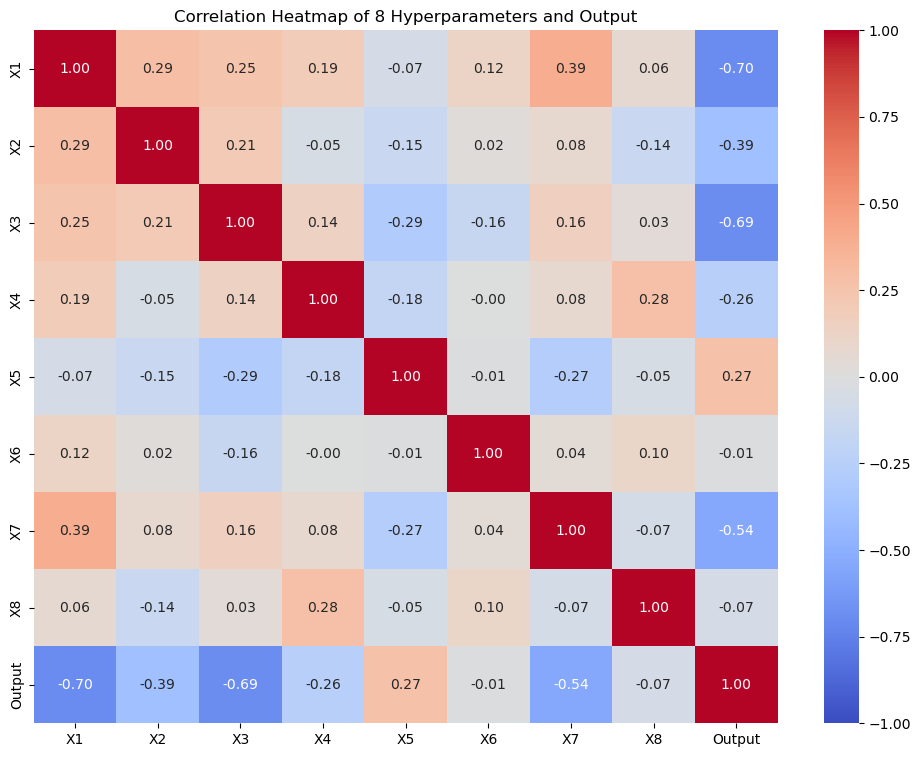

In [3]:
# --- 2.5. Correlation Heatmap Analysis ---
print("\n--- Correlation Analysis ---")

# Create feature names for the 8 dimensions
feature_names = [f'X{i+1}' for i in range(X_data.shape[1])]

# Create a Pandas DataFrame
df_X = pd.DataFrame(X_data, columns=feature_names)
df_Y = pd.DataFrame(Y_data, columns=['Output'])
df_full = pd.concat([df_X, df_Y], axis=1)

# Calculate the correlation matrix
corr_matrix = df_full.corr()

# Plot the heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix, 
    annot=True,     # Show the correlation values
    fmt=".2f",      # Format to 2 decimal places
    cmap="coolwarm", # Use a diverging color map
    vmin=-1, vmax=1   # Set the color range from -1 to 1
)
plt.title('Correlation Heatmap of 8 Hyperparameters and Output')
plt.savefig('f8_week4_correlation_heatmap.png', dpi=150, bbox_inches='tight')

# Display the correlation with the output specifically
print("Correlation with 'Output':")
# This shows us the simplest linear relationships in the data
print(corr_matrix['Output'].sort_values(ascending=False))